In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
class ParentState(TypedDict):

    question: str
    answer_eng: str
    answer_hin: str

In [4]:
parent_llm = ChatOpenAI(model='gpt-4o-mini')
subgraph_llm = ChatOpenAI(model='gpt-4o')

In [5]:
def translate_text(state: ParentState):

    prompt = f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text:
{state["answer_eng"]}
""".strip()

    translated_text = subgraph_llm.invoke(prompt).content

    return {'answer_hin': translated_text}

In [6]:
subgraph_builder = StateGraph(ParentState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()

In [8]:
def generate_answer(state: ParentState):

    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

In [9]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", subgraph)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

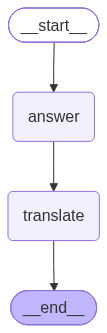

In [10]:

graph = parent_builder.compile()

graph

In [11]:
graph.invoke({'question': 'What is quantum physics'})

{'question': 'What is quantum physics',
 'answer_eng': "Quantum physics, or quantum mechanics, is a fundamental branch of physics that deals with the behavior of matter and energy at very small scales, typically at the level of atoms and subatomic particles. It fundamentally differs from classical physics, which describes the macroscopic world.\n\nKey principles of quantum physics include:\n\n1. **Wave-Particle Duality**: Particles, such as electrons and photons, exhibit both particle-like and wave-like properties. This means they can behave as discrete particles in some situations and as waves in others.\n\n2. **Quantization**: Certain properties, like energy, are quantized, meaning they can only take on discrete values. For example, electrons in an atom can only exist in specific energy levels.\n\n3. **Uncertainty Principle**: Formulated by Werner Heisenberg, this principle states that certain pairs of physical properties, like position and momentum, cannot be simultaneously measured